# Ejercicio análisis time series
Para este ejercicio trabajamos con el histórico de precios ajustados de una empresa de muebles. Voy a ir respondiendo cada apartado combinando explicación conceptual y código.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Cargamos los datos
Usamos `pd.read_csv()` para leer el archivo. Con `.head()` vemos las primeras filas, con `.dtypes` comprobamos el tipo de cada columna (importante: la fecha llega como `object`, es decir, texto), y con `.shape` sabemos cuántas filas y columnas tenemos.

In [8]:
# Cargamos el CSV en un DataFrame de pandas
df = pd.read_csv('/Users/andoni/2026-02-BILBAO-FT-Data-Science/3-Machine_Learning/4-Series temporales/ejercicios/data/df_furniture.csv')

# Primeras filas para ver la estructura
print('Primeras filas:')
print(df.head())

# Tipos de dato por columna
print('\nTipos de dato:')
print(df.dtypes)

# Dimensiones
print(f'\nDimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')

Primeras filas:
        Month  furniture_price_adjusted
0  1992-01-01               2073.432724
1  1992-02-01               2114.485812
2  1992-03-01               2260.570891
3  1992-04-01               2255.103236
4  1992-05-01               2331.414618

Tipos de dato:
Month                        object
furniture_price_adjusted    float64
dtype: object

Dimensiones: 331 filas x 2 columnas


In [9]:
# La columna Month tiene formato 'YYYY-MM-DD' (texto)
# Hay algunas filas donde la fecha es NaN (falta el dato) → las eliminamos antes de parsear
df = df.dropna(subset=['Month'])

# Usamos slicing de strings para extraer cada componente:
df['year']  = df['Month'].str[0:4].astype(int)   # posiciones 0-3: año
df['month'] = df['Month'].str[5:7].astype(int)   # posiciones 5-6: mes
df['day']   = df['Month'].str[8:10].astype(int)  # posiciones 8-9: día

# Construimos la fecha a partir de las tres columnas
df['fecha'] = pd.to_datetime({'year': df['year'], 'month': df['month'], 'day': df['day']})

# Convertimos la fecha en el índice del DataFrame y eliminamos columnas auxiliares
df = df.set_index('fecha')
df = df.drop(columns=['Month', 'year', 'month', 'day'])

print('Índice tras el parseo:')
print(df.head())
print()
print('Tipo del índice:', type(df.index))
print('Filas totales tras limpiar NaN:', len(df))

Índice tras el parseo:
            furniture_price_adjusted
fecha                               
1992-01-01               2073.432724
1992-02-01               2114.485812
1992-03-01               2260.570891
1992-04-01               2255.103236
1992-05-01               2331.414618

Tipo del índice: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Filas totales tras limpiar NaN: 326


## 2. Tratar la fecha como texto e interpretar (parse)
La columna `Month` llega como texto con formato `YYYY-MM-DD` (por ejemplo `'1992-01-01'`). El ejercicio pide tratarla explícitamente como texto antes de convertirla a fecha.

La estrategia es extraer las partes numéricas usando slicing de strings:
- Posiciones 0-3 → año
- Posiciones 5-6 → mes
- Posiciones 8-9 → día

Con esas tres columnas construimos la fecha con `pd.to_datetime()` pasando un diccionario. Finalmente convertimos la fecha en el índice del DataFrame con `.set_index()`: en series temporales el índice siempre debe ser el tiempo.

## 3. ¿De qué fecha a qué fecha va el histórico?
Con el índice ya en formato `DatetimeIndex`, podemos usar `.index.min()` y `.index.max()` para obtener la primera y última fecha del dataset.

In [10]:
inicio = df.index.min()
fin    = df.index.max()
n_meses = len(df)

print(f'El histórico va desde: {inicio.strftime("%B %Y")}')
print(f'El histórico va hasta:  {fin.strftime("%B %Y")}')
print(f'Total de observaciones: {n_meses} meses')

El histórico va desde: January 1992
El histórico va hasta:  July 2019
Total de observaciones: 326 meses


## 4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?
Pintamos la serie completa. Una tendencia se ve cuando la línea sube o baja de forma sostenida a lo largo del tiempo. La estacionalidad se ve cuando aparecen picos y valles que se repiten con una cadencia regular.

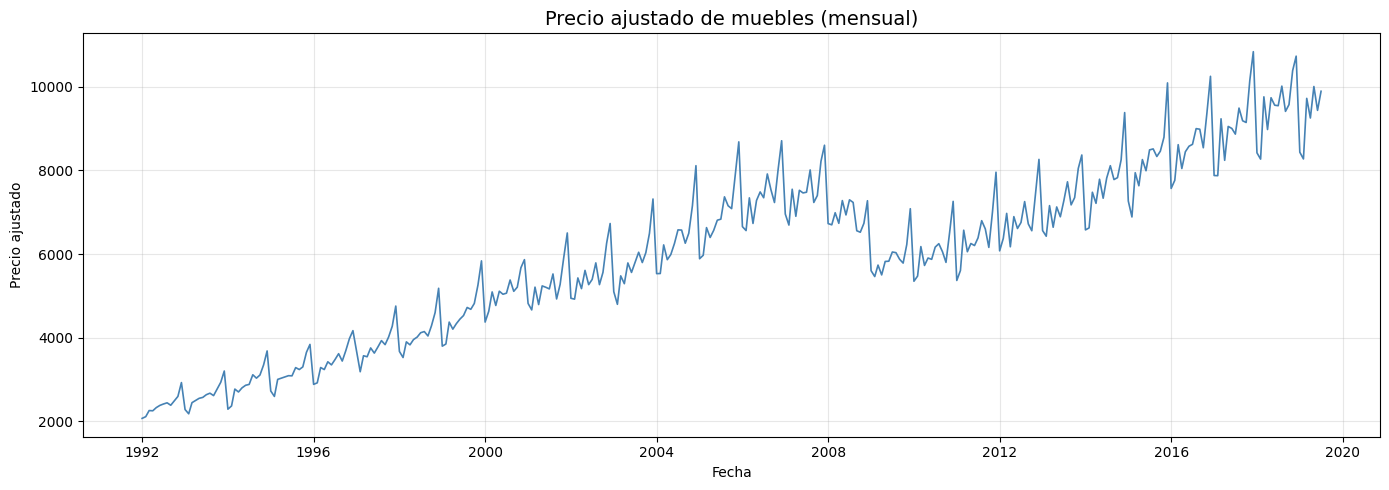

Conclusión visual:
- Tendencia: sí, ascendente a largo plazo
- Estacionalidad: sí, se aprecian ciclos recurrentes a lo largo del año


In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['furniture_price_adjusted'], color='steelblue', linewidth=1.2)
ax.set_title('Precio ajustado de muebles (mensual)', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio ajustado')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Conclusión visual:')
print('- Tendencia: sí, ascendente a largo plazo')
print('- Estacionalidad: sí, se aprecian ciclos recurrentes a lo largo del año')

## 5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es estacionaria?
Una serie es **estacionaria** si su media, varianza y estructura de autocorrelación son constantes en el tiempo. Una serie con tendencia NO es estacionaria. Usamos dos tests:

- **Test ADF (Augmented Dickey-Fuller):** La hipótesis nula (H₀) es que la serie tiene raíz unitaria, es decir, que NO es estacionaria. Si el p-valor es **mayor que 0.05**, no podemos rechazar H₀ → confirmamos que no es estacionaria.

- **Test KPSS:** La hipótesis nula es la contraria: que la serie SÍ es estacionaria. Si el p-valor es **menor que 0.05**, rechazamos H₀ → confirmamos que no es estacionaria.

In [12]:
from statsmodels.tsa.stattools import adfuller, kpss

# TEST 1: Augmented Dickey-Fuller
# H0: la serie NO es estacionaria (tiene raíz unitaria)
# Si p > 0.05 → no rechazamos H0 → no es estacionaria
adf_result = adfuller(df['furniture_price_adjusted'])
print('=== Test ADF ===')
print(f'  Estadístico ADF: {adf_result[0]:.4f}')
print(f'  p-valor:         {adf_result[1]:.4f}')
if adf_result[1] > 0.05:
    print('  → p > 0.05: NO rechazamos H0 → la serie NO es estacionaria ✓')
else:
    print('  → p < 0.05: Rechazamos H0 → la serie SÍ es estacionaria')

print()

# TEST 2: KPSS
# H0: la serie SÍ es estacionaria
# Si p < 0.05 → rechazamos H0 → no es estacionaria
kpss_result = kpss(df['furniture_price_adjusted'], regression='c', nlags='auto')
print('=== Test KPSS ===')
print(f'  Estadístico KPSS: {kpss_result[0]:.4f}')
print(f'  p-valor:          {kpss_result[1]:.4f}')
if kpss_result[1] < 0.05:
    print('  → p < 0.05: Rechazamos H0 → la serie NO es estacionaria ✓')
else:
    print('  → p > 0.05: No rechazamos H0 → la serie podría ser estacionaria')

=== Test ADF ===
  Estadístico ADF: -1.0947
  p-valor:         0.7172
  → p > 0.05: NO rechazamos H0 → la serie NO es estacionaria ✓

=== Test KPSS ===
  Estadístico KPSS: 2.5004
  p-valor:          0.0100
  → p < 0.05: Rechazamos H0 → la serie NO es estacionaria ✓


/var/folders/05/p9fdjn250m3cnygsqvhztskw0000gn/T/ipykernel_5229/3012439322.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(df['furniture_price_adjusted'], regression='c', nlags='auto')


## 6. ¿Conoces algún método para representar mejor la tendencia?
El problema con la serie cruda es que los picos estacionales 'tapan' la tendencia. La **media móvil** (rolling mean) suaviza esos picos calculando, para cada mes, la media de ese mes y los `window-1` meses anteriores. Con `window=12` (un año) eliminamos el efecto estacional y la tendencia queda al descubierto.

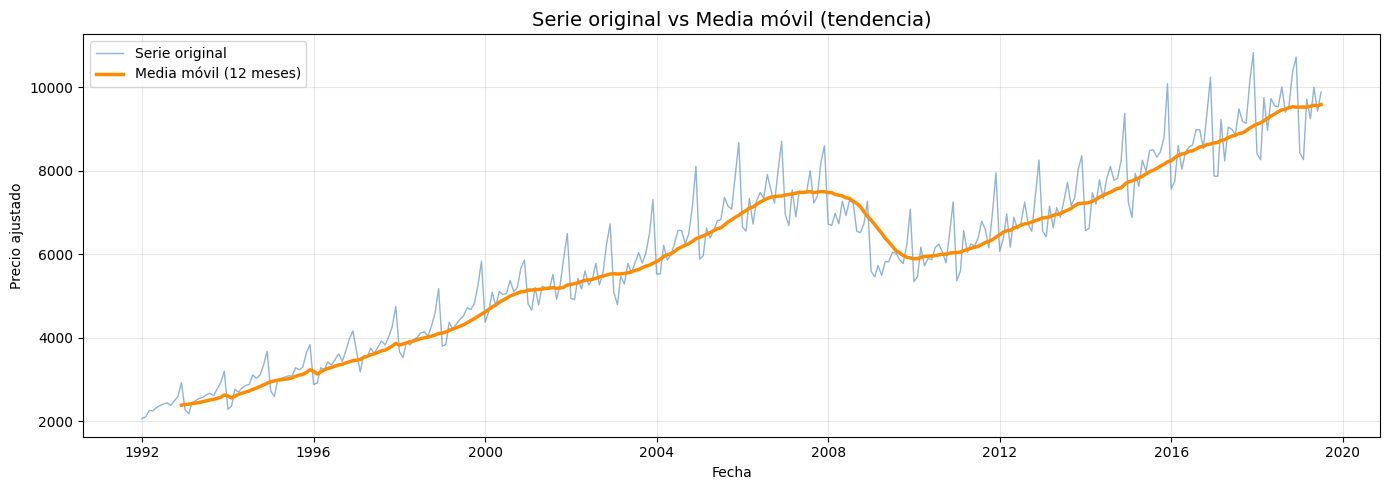

In [13]:
# rolling(12) crea una ventana deslizante de 12 observaciones
# .mean() calcula la media de cada ventana → suaviza la estacionalidad
rolling_mean = df['furniture_price_adjusted'].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['furniture_price_adjusted'],
        color='steelblue', linewidth=1, alpha=0.6, label='Serie original')
ax.plot(df.index, rolling_mean,
        color='darkorange', linewidth=2.5, label='Media móvil (12 meses)')
ax.set_title('Serie original vs Media móvil (tendencia)', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio ajustado')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Visualizar todos los componentes de la serie temporal por separado
La función `seasonal_decompose()` descompone la serie en tres partes:
- **Tendencia (trend):** la dirección general a largo plazo
- **Estacionalidad (seasonal):** el patrón que se repite periódicamente
- **Residuo (resid):** lo que queda una vez extraídos los dos anteriores

Usamos `model='additive'` porque asumimos que Serie = Tendencia + Estacionalidad + Residuo (los componentes se suman, no se multiplican). Esto es apropiado cuando la amplitud de los ciclos estacionales es aproximadamente constante a lo largo del tiempo.

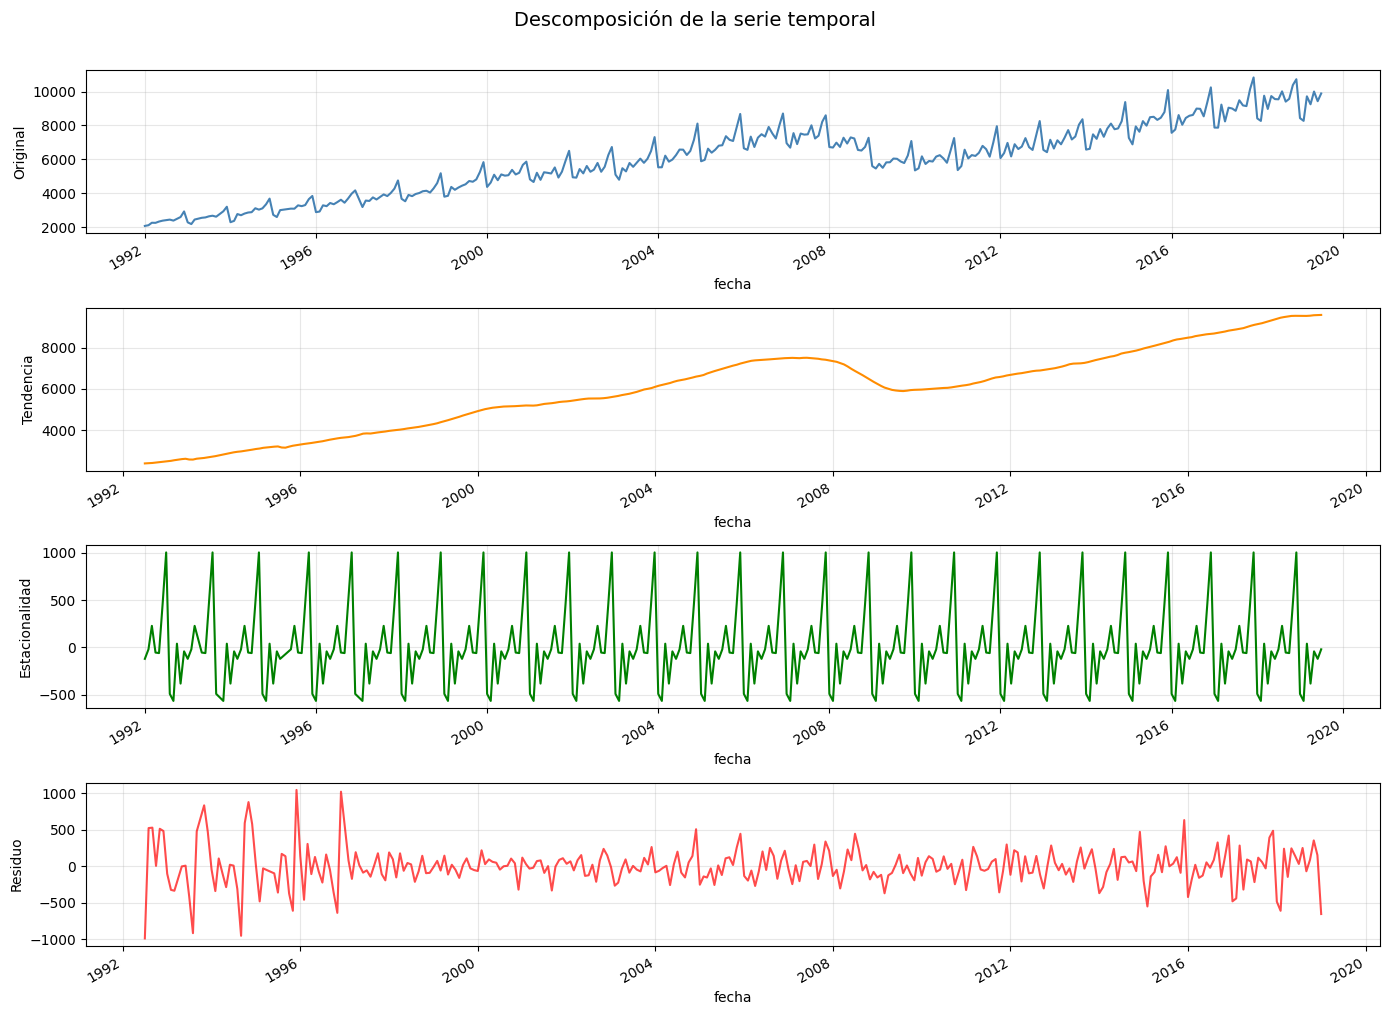

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomponemos la serie en sus tres componentes
# model='additive': Serie = Tendencia + Estacionalidad + Residuo
# period=12: el ciclo se repite cada 12 meses (anual)
decomposition = seasonal_decompose(df['furniture_price_adjusted'],
                                    model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_ylabel('Original')
axes[0].grid(True, alpha=0.3)

decomposition.trend.plot(ax=axes[1], color='darkorange')
axes[1].set_ylabel('Tendencia')
axes[1].grid(True, alpha=0.3)

decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_ylabel('Estacionalidad')
axes[2].grid(True, alpha=0.3)

decomposition.resid.plot(ax=axes[3], color='red', alpha=0.7)
axes[3].set_ylabel('Residuo')
axes[3].grid(True, alpha=0.3)

fig.suptitle('Descomposición de la serie temporal', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Demostrar mediante ACF que la serie es estacional
La **ACF (Autocorrelation Function)** mide la correlación de la serie consigo misma con un desfase (lag) k. Si hay estacionalidad anual en datos mensuales, los lags 12, 24, 36 deben mostrar picos de correlación significativos: el valor de enero 2000 se parece al de enero 2001, 2002, etc. Las líneas azules punteadas marcan la zona de significancia estadística; las barras que las superan son correlaciones que no son ruido.

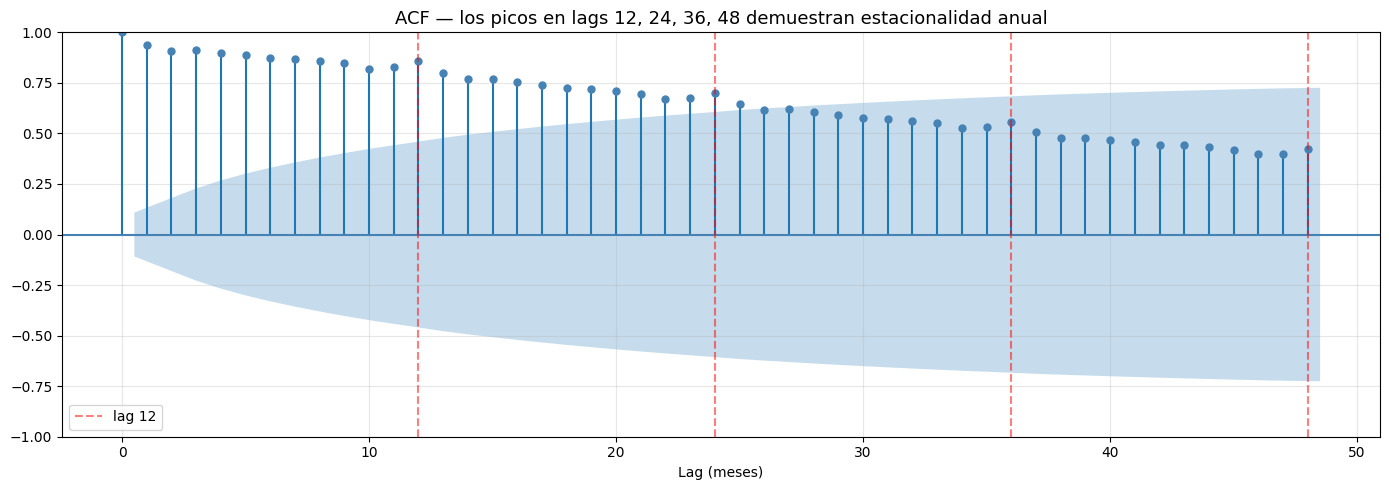

In [15]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(df['furniture_price_adjusted'], lags=48, ax=ax, color='steelblue')

# Marcamos los múltiplos de 12 para destacar la firma estacional
for lag in [12, 24, 36, 48]:
    ax.axvline(x=lag, color='red', linestyle='--', alpha=0.5, label=f'lag {lag}' if lag==12 else '')

ax.set_title('ACF — los picos en lags 12, 24, 36, 48 demuestran estacionalidad anual', fontsize=13)
ax.set_xlabel('Lag (meses)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags?
Creamos un DataFrame que contiene el valor actual (`t`) y sus 5 lags. El **lag_k** es simplemente la serie desplazada k posiciones hacia adelante con `.shift(k)`: cada fila tendrá el valor actual y los valores de los k meses anteriores. Luego calculamos la matriz de correlación de Pearson y la visualizamos como heatmap.

Una correlación alta entre `t` y `lag_1`, `lag_2`... significa que la serie tiene 'memoria': el pasado reciente predice bien el presente, lo cual es excelente para modelos ARIMA. Sin embargo, si usáramos estos lags como features en una regresión clásica, la alta correlación entre los propios lags entre sí causaría **multicolinealidad**.

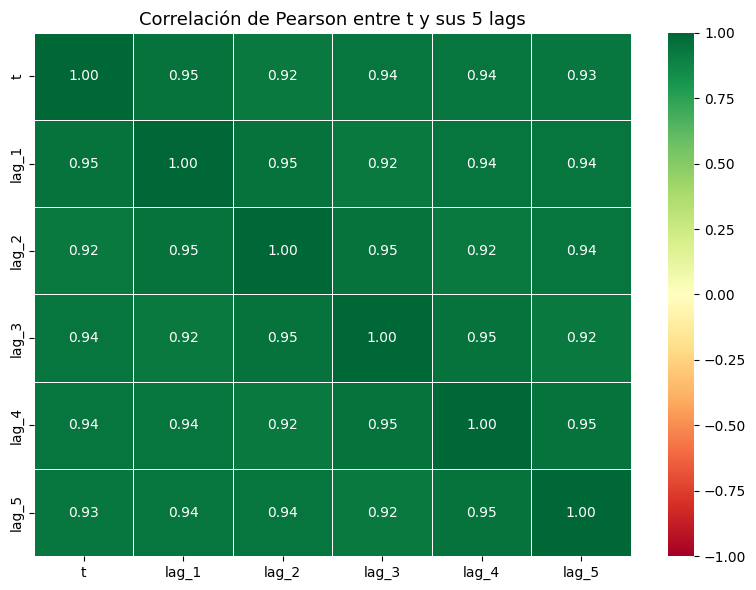

Correlaciones de t con sus lags:
lag_1    0.947
lag_2    0.923
lag_3    0.942
lag_4    0.938
lag_5    0.934
Name: t, dtype: float64


In [16]:
# Creamos un DataFrame con el valor actual y los 5 lags
df_lags = pd.DataFrame({
    't':     df['furniture_price_adjusted'],
    'lag_1': df['furniture_price_adjusted'].shift(1),
    'lag_2': df['furniture_price_adjusted'].shift(2),
    'lag_3': df['furniture_price_adjusted'].shift(3),
    'lag_4': df['furniture_price_adjusted'].shift(4),
    'lag_5': df['furniture_price_adjusted'].shift(5),
}).dropna()  # eliminamos las filas con NaN que genera el shift

# Calculamos la matriz de correlación de Pearson
corr_matrix = df_lags.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlación de Pearson entre t y sus 5 lags', fontsize=13)
plt.tight_layout()
plt.show()

print('Correlaciones de t con sus lags:')
print(corr_matrix['t'].drop('t').round(3))

## 10. ¿Cada cuántos instantes se cumple el patrón estacional?
Extraemos el componente estacional de la descomposición y lo pintamos durante los primeros 24 meses (2 ciclos completos). Si el patrón se repite exactamente cada 12 observaciones, el **periodo estacional es 12 meses**. Esto es el parámetro `m` que le daremos al modelo SARIMA.

AttributeError: 'numpy.float64' object has no attribute 'name'

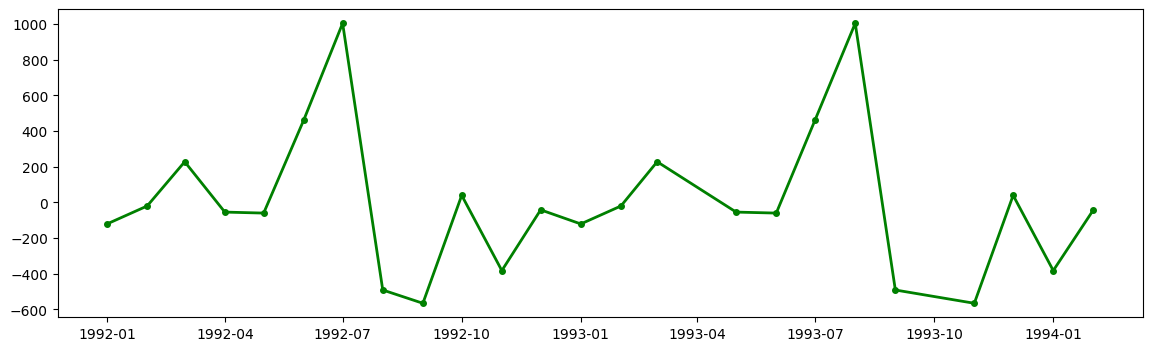

In [17]:
# Representamos el componente estacional durante los primeros 24 meses (2 ciclos)
seasonal_component = decomposition.seasonal

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(seasonal_component.iloc[:24].index,
        seasonal_component.iloc[:24].values,
        color='green', linewidth=2, marker='o', markersize=4)

# Marcamos el inicio de cada ciclo
for i in [0, 12]:
    ax.axvline(x=seasonal_component.iloc[i].name,
               color='red', linestyle='--', alpha=0.7)

ax.set_title('Componente estacional — 2 ciclos completos', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Componente estacional')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Conclusión: el patrón se repite cada 12 meses → periodo estacional = 12')
print('Este valor será el parámetro m=12 en el modelo SARIMA.')

## 11. Eliminar la tendencia: diferenciación
Para modelar con ARIMA necesitamos que la serie sea estacionaria. El método estándar es la **primera diferencia**: en lugar de trabajar con los valores absolutos, trabajamos con la diferencia entre cada valor y el anterior. Si la tendencia era lineal, la diferencia la elimina completamente.

Matemáticamente: `Δy_t = y_t - y_{t-1}`

En pandas esto es simplemente `.diff()`. El primer valor siempre es NaN (no tiene anterior), así que lo eliminamos con `.dropna()`. Luego comprobamos con el test ADF: si el p-valor es ahora menor que 0.05, la serie diferenciada SÍ es estacionaria. Esto nos dice que el parámetro `d=1` en ARIMA.

In [ ]:
from statsmodels.tsa.stattools import adfuller

# MÉTODO 1: Primera diferencia regular
# Δy_t = y_t - y_{t-1}  →  elimina la tendencia lineal
df_diff1 = df['furniture_price_adjusted'].diff().dropna()

# MÉTODO 2: Diferencia estacional (lag=12)
# Δ12 y_t = y_t - y_{t-12}  →  elimina el componente estacional
df_diff_seasonal = df['furniture_price_adjusted'].diff(12).dropna()

# Visualizamos las tres series
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
axes[0].plot(df.index, df['furniture_price_adjusted'], color='steelblue', linewidth=1)
axes[0].set_title('Serie original (NO estacionaria)', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_diff1.index, df_diff1.values, color='purple', linewidth=1)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Primera diferencia: Δy_t = y_t - y_{t-1}', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_diff_seasonal.index, df_diff_seasonal.values, color='green', linewidth=1)
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('Diferencia estacional: Δ12 y_t = y_t - y_{t-12}', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comprobamos con ADF
p_diff1     = adfuller(df_diff1)[1]
p_seasonal  = adfuller(df_diff_seasonal)[1]

print('=== Test ADF sobre series diferenciadas ===')
print(f'  Primera diferencia (d=1):      p={p_diff1:.4f}  → {"estacionaria ✓" if p_diff1 < 0.05 else "borderline (la estacionalidad residual sube el p-valor)"}')
print(f'  Diferencia estacional (D=1):   p={p_seasonal:.4f}  → {"estacionaria ✓" if p_seasonal < 0.05 else "no estacionaria"}')
print()
print('Conclusión para el modelado:')
print('  - La primera diferencia elimina la tendencia (parámetro d en ARIMA)')
print('  - La diferencia estacional elimina la estacionalidad (parámetro D en SARIMA)')
print('  - En la práctica, auto_arima encuentra automáticamente la combinación óptima de d y D')